In [1]:
#loading filtered rna and atac data
import anndata
from anndata import AnnData
import pandas as pd
import numpy as np

pb_atac_ct_time = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes_times/agg_atac_ct_time.h5ad")
pb_rna_ct_time = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/RNA/celltypes_times/agg_rna_ct_time.h5ad")    
gene_peaks_10kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/gene_peak_assignments_10kb.csv")
gene_peaks_20kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/gene_peak_assignments_20kb.csv")
gene_peaks_50kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/gene_peak_assignments_50kb.csv")
gene_peaks_100kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/gene_peak_assignments_100kb.csv")

In [2]:
pb_atac_ct_time.obs_names.unique().size, pb_rna_ct_time.obs_names.unique().size

(196, 196)

In [3]:
#taking the minimum non-zero value in the pb_rna_ct_time matrix to add it to all values before log transformation to avoid taking log of zero
import numpy as np
non_zero_mask = (pb_rna_ct_time.X > 0)
epsilon_rna = np.min(pb_rna_ct_time.X[non_zero_mask])

#taking the minimum non-zero value in the pb_atac_ct_time matrix to add it to all values before log transformation to avoid taking log of zero
non_zero_mask = (pb_atac_ct_time.X > 0)
epsilon_at= np.min(pb_atac_ct_time.X[non_zero_mask])

In [4]:
#log transformation (for norm. distribution) & scaling 10000000+1
#log scaling both datasets by multiplying by 10 million and adding 1 to avoid log(0) issues, then taking log10
pb_rna_ct_time.X = np.log10((pb_rna_ct_time.X+ epsilon_rna)*10000000)
pb_atac_ct_time.X = np.log10((pb_atac_ct_time.X+ epsilon_at)*10000000)
print(pb_atac_ct_time.X)
print(pb_rna_ct_time.X)

[[ 0.58441806  0.3880675   1.06160453 ...  0.77350882  4.31687307
   4.26583112]
 [ 0.55057849  0.77497146  1.06311131 ...  0.71223775  4.46490082
   4.42605741]
 [ 0.5812014   0.31814683  1.47411151 ...  0.5812014   4.29971273
   4.26136205]
 ...
 [ 0.68050573  1.00535566  1.21338458 ...  0.87262121  4.28769769
   4.24816241]
 [ 0.56626071  0.77136092  1.20173285 ...  0.96576803  4.32052555
   4.22963983]
 [-0.4579541  -0.4579541   0.93853073 ... -0.4579541   4.43176072
   4.34928772]]
[[1.25848578 0.87479245 1.20428309 ... 4.57135069 0.72978795 0.04624963]
 [1.29820203 0.76356469 1.02082851 ... 4.59115367 1.18129282 0.76356469]
 [0.9837023  1.0959172  1.50987238 ... 4.60309939 0.9837023  1.18501005]
 ...
 [0.04624963 0.04624963 0.94900871 ... 4.66963744 0.04624963 0.04624963]
 [1.15741357 0.04624963 1.44129868 ... 4.6874499  0.04624963 1.44129868]
 [0.04624963 1.46040775 1.63088453 ... 4.6812724  0.04624963 0.04624963]]


In [5]:
gene_peaks_100kb[0:10]

,gene_id,assigned_peaks
0,rpl24,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
1,cep97,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
2,nfkbiz,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
3,eed,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
4,hikeshi,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
5,tmem39a,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
6,ildr1a,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
7,gpa33a,"['1-32-526', '1-2372-3057', '1-3427-4032', '1-..."
8,f7l,"['1-11007-12962', '1-13276-13705', '1-14059-14..."
9,f7,"['1-21199-21555', '1-21590-23611', '1-27097-29..."


# Computing normal OLS on all windows 

In [6]:
#check the maximum number of peaks assigned to each gene in all windows
import ast  
gene_peaks_10kb["num_assigned_peaks"] = gene_peaks_10kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0)
gene_peaks_20kb["num_assigned_peaks"] = gene_peaks_20kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0)
gene_peaks_50kb["num_assigned_peaks"] = gene_peaks_50kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0)
gene_peaks_100kb["num_assigned_peaks"] = gene_peaks_100kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0)
print(gene_peaks_10kb[["gene_id", "num_assigned_peaks"]].max())
print(gene_peaks_20kb[["gene_id", "num_assigned_peaks"]].max())
print(gene_peaks_50kb[["gene_id", "num_assigned_peaks"]].max())
print(gene_peaks_100kb[["gene_id", "num_assigned_peaks"]].max())

#number of samples in the pseudobulk datasets
print(pb_rna_ct_time.n_obs)
print(pb_atac_ct_time.n_obs)

gene_id               zzz3
num_assigned_peaks      17
dtype: object
gene_id               zzz3
num_assigned_peaks      32
dtype: object
gene_id               zzz3
num_assigned_peaks      69
dtype: object
gene_id               zzz3
num_assigned_peaks     125
dtype: object
196
196


In [8]:
#computing OLS regression for all windows by loading the function from the src folder 
from pathlib import Path
import sys

src_path = Path("/home/fgsasse_lrs_1/Downloads/BA/src/")

if str(src_path) not in sys.path:
       sys.path.insert(0, str(src_path)),

#import several functions from the src folder to classify peak-gene pairs and aggregate results
from your_package.ols import (
    compute_peak_gene_ols,
    classify_peak_gene_pairs,
    aggregate_peak_gene_categories)

ols_results = {}
ols_dfs = {}
agg_ols_dfs = {}

gene_peak_dict = {
    "10kb": gene_peaks_10kb,
    "20kb": gene_peaks_20kb,
    "50kb": gene_peaks_50kb,
    "100kb": gene_peaks_100kb,
}

window_label = ["10kb", "20kb", "50kb", "100kb"]

for window in window_label:

    print(f"Computing OLS regression for {window} window...")

    ols_results[window], ols_dfs[window] = compute_peak_gene_ols(
        rna_data=pb_rna_ct_time,
        atac_data=pb_atac_ct_time,
        gene_peaks_df=gene_peak_dict[window],
        window_label=window,
    )

    ols_dfs[window] = classify_peak_gene_pairs(
        ols_dfs[window]
    )

    agg_ols_dfs[window] = aggregate_peak_gene_categories(
        ols_dfs[window]
    )

agg_ols_dfs[window].head()

Computing OLS regression for 10kb window...
[10kb] OLS complete — 19380 genes processed
OLS DataFrame: 172,007 peak–gene pairs
Computing OLS regression for 20kb window...
[20kb] OLS complete — 19380 genes processed
OLS DataFrame: 360,340 peak–gene pairs
Computing OLS regression for 50kb window...
[50kb] OLS complete — 19380 genes processed
OLS DataFrame: 922,652 peak–gene pairs
Computing OLS regression for 100kb window...
[100kb] OLS complete — 19380 genes processed
OLS DataFrame: 1,853,529 peak–gene pairs


,window,gene,category,count
0,100kb,a1cf,non-significant,89
1,100kb,a1cf,sig. negative,2
2,100kb,a1cf,sig. positive,4
3,100kb,a2ml,non-significant,77
4,100kb,aaas,non-significant,102


In [12]:
#summarize all OLS results (all_ols_dfs) into a single dataframe for easier comparison across windows
all_ols_dfs = pd.concat(ols_dfs.values(), ignore_index=True)
all_ols_dfs["window"].unique()

#save the all_ols_dfs dataframe to a csv file for downstream analysis and visualization
all_ols_dfs.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_df_ct_time.csv", index=False)

## Plotting the OLS results

In [40]:
#read in the saved all_ols_dfs dataframe to confirm it was saved correctly
ols_all_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_df_ct_time.csv")
ols_all_df.head()

#aggregate the number of significant peaks per gene and category  
agg_ols_all_df = (
    ols_all_df
    .dropna(subset=["pval", "coef", "category"])
    .groupby(["window", "gene", "category"]) 
    .size()
    .reset_index(name="count")
)

In [18]:
agg_ols_all_df.head()

,window,gene,category,count
0,100kb,a1cf,non-significant,89
1,100kb,a1cf,sig. negative,2
2,100kb,a1cf,sig. positive,4
3,100kb,a2ml,non-significant,77
4,100kb,aaas,non-significant,102


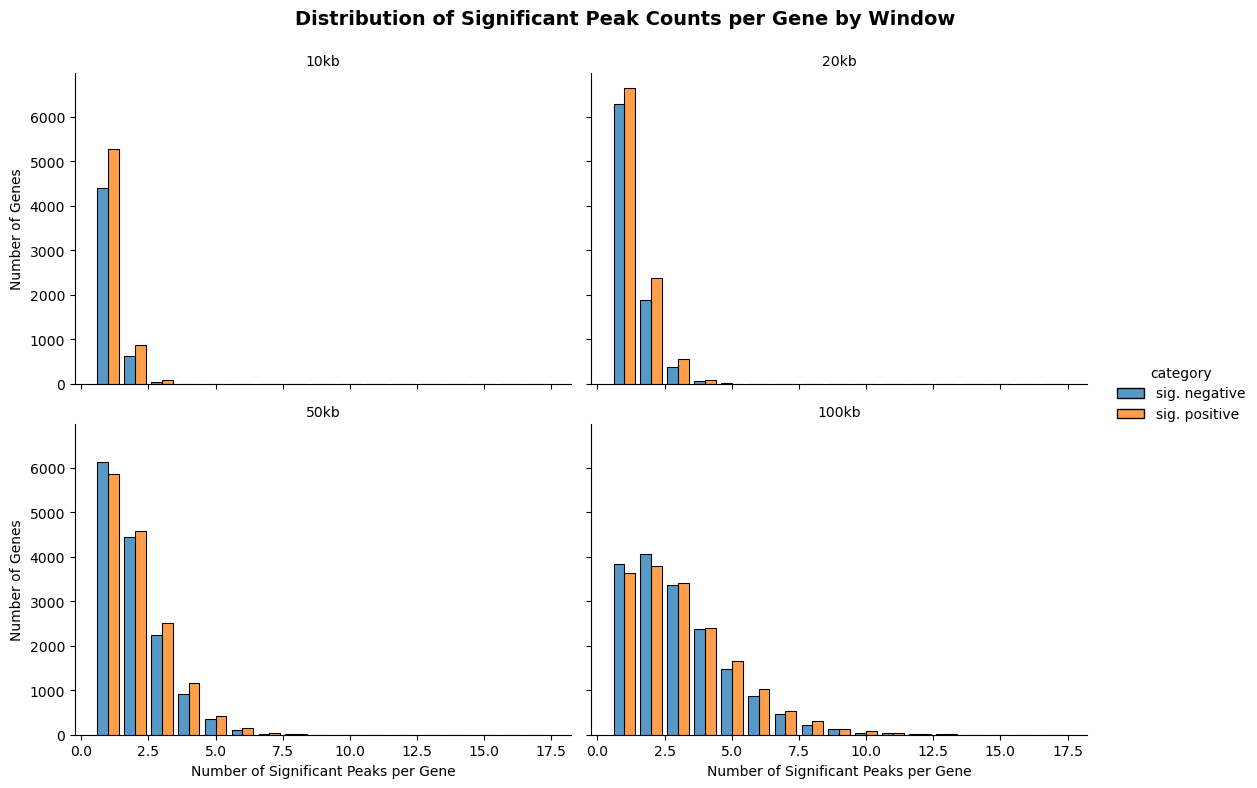

In [28]:
# plot the significant peak counts across all genes for the all windows using seaborn histplot, with separate colors for sig. positive and sig. negative categories
import matplotlib.pyplot as plt
import seaborn as sns

category_order = ["sig. negative", "sig. positive"]
agg_ols_all_df_non = agg_ols_all_df[agg_ols_all_df["category"] != "non-significant"]

plot = sns.displot(
    data=agg_ols_all_df_non,
    x="count",
    hue="category",
    hue_order=category_order,
    col="window",
    col_order=["10kb", "20kb", "50kb", "100kb"],
    col_wrap=2,          # <- 2 columns => 2x2 layout
    multiple="dodge",
    discrete=True,
    shrink=0.8,
    height=4,
    aspect=1.4,
)

plot.set_axis_labels(
    "Number of Significant Peaks per Gene",
    "Number of Genes",
)

plot.set_titles("{col_name}")

plot.figure.suptitle(
    "Distribution of Significant Peak Counts per Gene by Window",
    fontsize=14,
    fontweight="bold",
)

plot.figure.subplots_adjust(top=0.90)

plt.show()

## Deduplication

In [2]:
#read in the saved all_ols_dfs dataframe to confirm it was saved correctly
import pandas as pd
ols_all_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_df_ct_time.csv")
print(ols_all_df.head())

# Make window categorical and ordered
ols_all_df["window"] = pd.Categorical(
    ols_all_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True
)

# Order by window
ols_all_df = ols_all_df.sort_values("window",ascending=True)
print(ols_all_df[["window", "gene", "peak", "coef", "pval", "category"]].head())

#"Dedublication" of gene-peak pairs by keeping only the first occurrence of each pair across all windows (since they are ordered by window size, this will keep the pair with the smallest window size)"
pair_summary = (
    ols_all_df
    .groupby(["gene", "peak"], as_index=False)
    .first()
)

#Sort by window to keep the smallest window size for each gene-peak pair
pair_summary = pair_summary.sort_values("window", ascending=True)
print(pair_summary[["window", "gene", "peak", "coef", "pval", "category"]].head())

#Sanity check to confirm that each gene-peak pair is now unique
pair_counts = pair_summary.groupby(["gene", "peak"]).size().reset_index(name="count")
print(pair_counts['count'].value_counts()) # Should show that all pairs have a count of 1

#Counts how many unique gene-peak pairs fall into each category for each window size
summary_counts = (pair_summary.groupby(["window", "gene", "category"]).size().reset_index(name="count"))
summary_counts.head()


  window   gene           peak      coef      pval         category
0   10kb  rpl24    1-2372-3057  0.011235  0.374666  non-significant
1   10kb  rpl24    1-3427-4032 -0.009406  0.551328  non-significant
2   10kb  rpl24    1-4469-7268  0.029201  0.073043  non-significant
3   10kb  rpl24    1-9541-9969 -0.021557  0.073163  non-significant
4   10kb  rpl24  1-11007-12962  0.016918  0.307889  non-significant
       window        gene                  peak      coef      pval  \
0        10kb       rpl24           1-2372-3057  0.011235  0.374666   
114667   10kb  tmem176l.2  16-46638153-46638527  0.021863  0.496528   
114668   10kb  tmem176l.2  16-46638664-46638958 -0.036179  0.257149   
114669   10kb  tmem176l.2  16-46639037-46639521  0.013231  0.663456   
114670   10kb  tmem176l.2  16-46640131-46640616  0.029326  0.351462   

               category  
0       non-significant  
114667  non-significant  
114668  non-significant  
114669  non-significant  
114670  non-significant  
        w

/tmp/ipykernel_3649541/2032477553.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_counts = (pair_summary.groupby(["window", "gene", "category"]).size().reset_index(name="count"))


,window,gene,category,count
0,10kb,a1cf,non-significant,11
1,10kb,a1cf,sig. negative,0
2,10kb,a1cf,sig. positive,0
3,10kb,a2ml,non-significant,11
4,10kb,a2ml,sig. negative,0


/tmp/ipykernel_3649541/27108511.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])


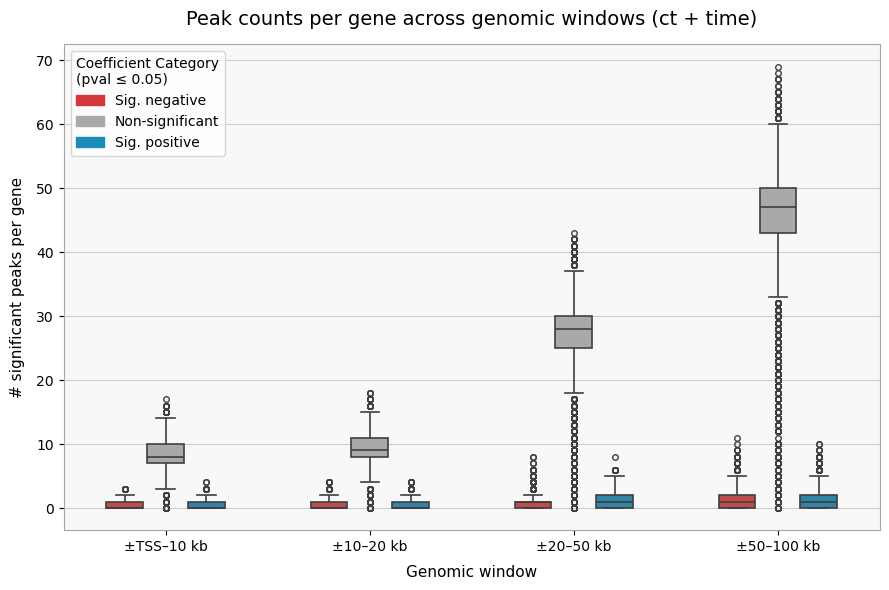

In [3]:
#Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for each category and window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
    "non-significant": "#A9A9A9",
}

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=summary_counts,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "10kb":  "±TSS–10 kb",
    "20kb":  "±10–20 kb",
    "50kb":  "±20–50 kb",
    "100kb": "±50–100 kb",
}
ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in summary_counts["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows (ct + time)",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("# significant peaks per gene", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(
    handles=handles,
    title="Coefficient Category\n(pval ≤ 0.05)",
    frameon=True,
    fontsize=10,
    loc="upper left",
    title_fontsize=10,
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3649541/2764027710.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])


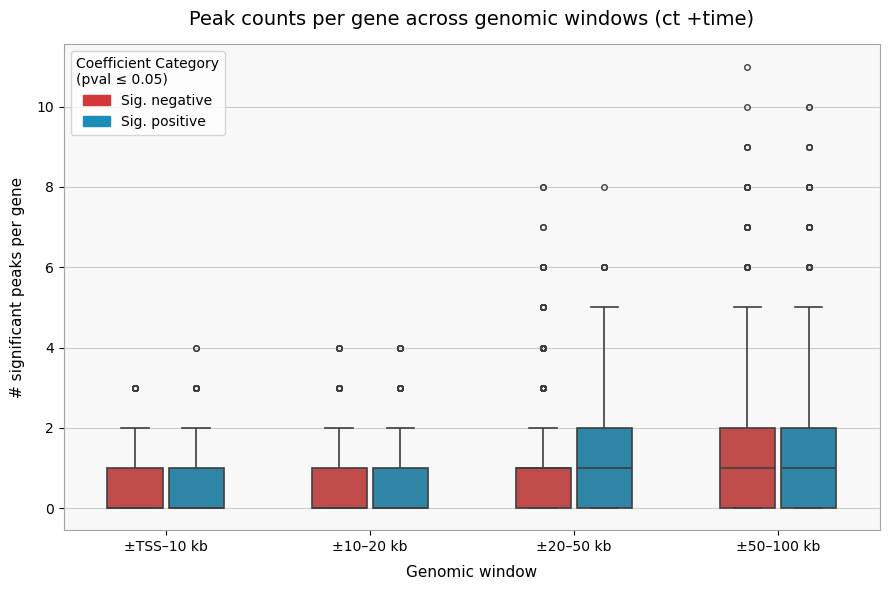

In [4]:
# Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for significant categories only (non-significant category excluded) for each window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
}

only_sig = summary_counts[summary_counts["category"] != "non-significant"]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=only_sig,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "10kb":  "±TSS–10 kb",
    "20kb":  "±10–20 kb",
    "50kb":  "±20–50 kb",
    "100kb": "±50–100 kb",
}
ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in only_sig["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows (ct +time)",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("# significant peaks per gene", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(
    handles=handles,
    title="Coefficient Category\n(pval ≤ 0.05)",
    frameon=True,
    fontsize=10,
    loc="upper left",
    title_fontsize=10,
)

plt.tight_layout()
plt.show()

## Plotting OLS results vs Correlation results

In [3]:
#read in the results from correlation analysis, then aggregate
cor_res_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_ct_time_results.csv")
cor_res_df.head()

# classify every peak–gene pair into one of three categories
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_df["category"] = cor_res_df.apply(classify_pair, axis=1)

#aggregate the number of significant peaks per gene and category  
agg_cor_all_windows_df = (
    cor_res_df
    .dropna(subset=["correlation", "padj", "category"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)
agg_cor_all_windows_df.head()

,window,gene,category,count
0,100kb,a1cf,non-significant,70
1,100kb,a1cf,sig. positive,25
2,100kb,a2ml,non-significant,68
3,100kb,a2ml,sig. positive,9
4,100kb,aaas,non-significant,94


In [4]:
#read in the saved all_ols_dfs dataframe to confirm it was saved correctly
ols_res_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_res_all_windows_df_ct_time.csv")

#aggregate the number of significant peaks per gene and category for OLS results
agg_ols_all_df = (
    ols_res_df
    .dropna(subset=["pval", "coef", "category"])
    .groupby(["window", "gene", "category"]) 
    .size()
    .reset_index(name="count")
)

agg_ols_all_df["window"] = pd.Categorical( 
    agg_ols_all_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)

In [5]:
#merge the two aggregated dataframes on window, gene to compare the number of significant peaks per gene and category between correlation and OLS results

#rename the count column in agg_cor_all_windows_df to count_cor to avoid confusion with the count column in agg_ols_all_windows_df
agg_cor_all_windows_df["count_cor"] = agg_cor_all_windows_df['count']
agg_ols_all_df["count_ols"] = agg_ols_all_df['count']

agg_merged_df = pd.merge(
    agg_cor_all_windows_df,
    agg_ols_all_df,
    on=["window", "gene", "category"],
    how="outer",
)
agg_merged_df.head() 

,window,gene,category,count_x,count_cor,count_y,count_ols
0,100kb,a1cf,non-significant,70.0,70.0,89.0,89.0
1,100kb,a1cf,sig. negative,NaN,NaN,2.0,2.0
2,100kb,a1cf,sig. positive,25.0,25.0,4.0,4.0
3,100kb,a2ml,non-significant,68.0,68.0,77.0,77.0
4,100kb,a2ml,sig. positive,9.0,9.0,NaN,NaN


/tmp/ipykernel_3338965/1587964733.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_sig_df["n_genes"] = plot_sig_df.groupby(


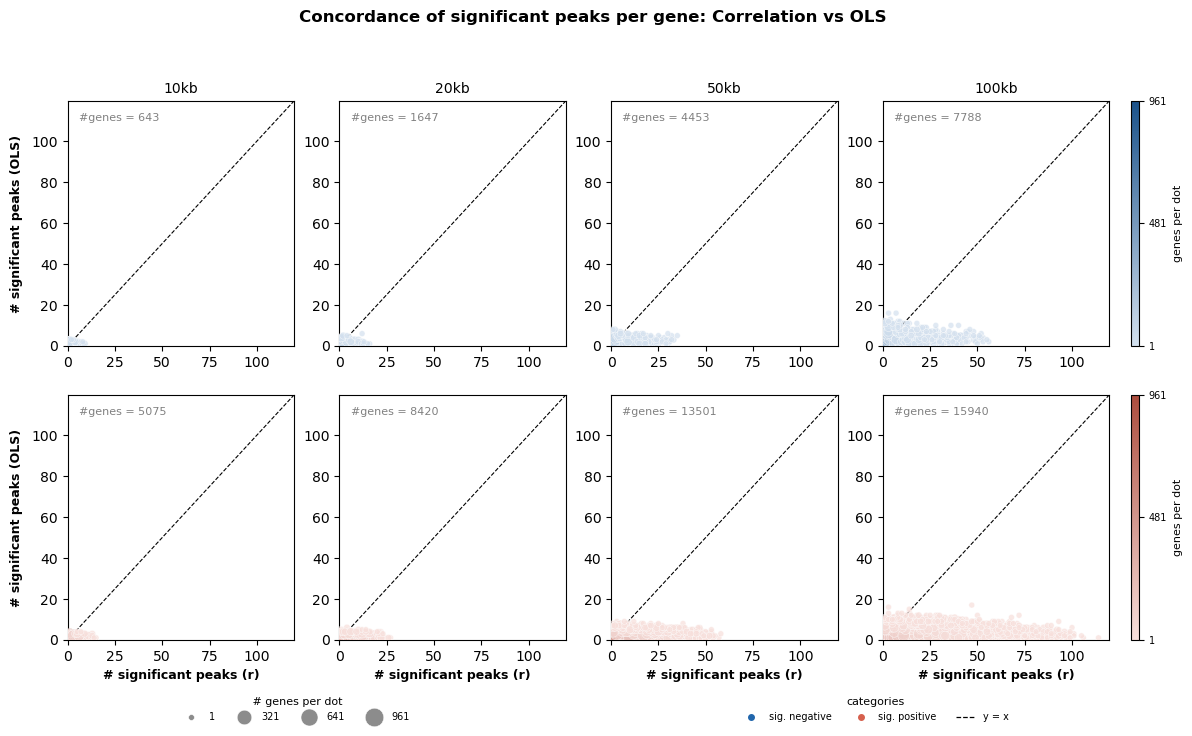

In [ ]:
#plot the number of significant peaks per gene in correlation vs OLS results, colored by category and faceted by window & category
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["10kb", "20kb", "50kb", "100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df[plot_df["category"] != "non-significant"].copy()

# Count genes per (count_cor, count_ols, window, category) position
plot_sig_df["n_genes"] = plot_sig_df.groupby(
    ["window", "category", "count_cor", "count_ols"] 
)["gene"].transform("count")

category_base_colors = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
}
category_order = ["sig. negative", "sig. positive"]
windows = ["10kb", "20kb", "50kb", "100kb"]

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["count_cor", "count_ols", "window", "category"]
).copy()

# Global n_genes range for consistent size/color scaling
n_min = plot_dedup["n_genes"].min()
n_max = plot_dedup["n_genes"].max()

def make_alpha_cmap(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    light = (1 - (1 - r) * 0.20, 1 - (1 - g) * 0.20, 1 - (1 - b) * 0.20)
    dark  = (r * 0.8, g * 0.8, b * 0.8)
    return mcolors.LinearSegmentedColormap.from_list("cat_cmap", [light, dark])
# ↑ removed hex_color midpoint — now light=n_min, dark=n_max, linear between them


def size_scale(n, n_min, n_max, s_min=18, s_max=180):
    """Map gene count to marker area (sqrt scaling feels more linear visually)."""
    if n_max == n_min:
        return (s_min + s_max) / 2
    return s_min + (s_max - s_min) * ((n - n_min) / (n_max - n_min)) ** 0.5

# plot: rows = categories, cols = windows, points colored by category 
fig, axes = plt.subplots(
    len(category_order), len(windows),
    figsize=(14, 7),
    sharex=False, sharey=False,
)

axis_max = plot_sig_df[["count_cor", "count_ols"]].max().max() * 1.05

for row_i, category in enumerate(category_order):
    cmap = make_alpha_cmap(category_base_colors[category])
    norm = Normalize(vmin=n_min, vmax=n_max) 
     # ✓ one colorbar per row, attached to the rightmost axis
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes[row_i, :],   # spans all axes in this row
        orientation="vertical",
        fraction=0.02,        # thin bar
        pad=0.02,
        aspect=30,
    )
    cbar.set_label("genes per dot", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    # tick at n_min, midpoint, n_max
    cbar.set_ticks([n_min, (n_min + n_max) // 2, n_max])

    for col_i, window in enumerate(windows):
        ax = axes[row_i, col_i]
        data = plot_dedup[
            (plot_dedup["window"] == window) &
            (plot_dedup["category"] == category)
        ]

        if not data.empty:
            sizes  = data["n_genes"].apply(lambda n: size_scale(n, n_min, n_max))
            colors = cmap(norm(data["n_genes"]))

            ax.scatter(
                data["count_cor"], data["count_ols"],
                s=sizes, c=colors,
                edgecolors="w", linewidths=0.4, zorder=3, alpha =0.7,
            )

        ax.plot([0, axis_max], [0, axis_max],
                color="k", linestyle="--", linewidth=0.8, zorder=0)
        ax.set_xlim(0, axis_max)
        ax.set_ylim(0, axis_max)

        if row_i == 0:
            ax.set_title(window, fontsize=10)
        if col_i == 0:
            ax.set_ylabel("# significant peaks (OLS)", fontsize=9, labelpad=6,fontweight="bold")
        else:
            ax.set_ylabel("")
        if row_i == len(category_order) - 1:
            ax.set_xlabel("# significant peaks (r)", fontsize=9,fontweight="bold")
        else:
            ax.set_xlabel("")

        n_total = data["n_genes"].sum()
        ax.text(0.05, 0.95, f"#genes = {n_total}", transform=ax.transAxes,
                ha="left", va="top", fontsize=8, color="0.5")

# ── Legend: size scale ────────────────────────────────────────────────────────
legend_counts = np.linspace(n_min, n_max, 4).astype(int)
size_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markersize=np.sqrt(size_scale(n, n_min, n_max)),  # radius from area 
           markerfacecolor="0.55", markeredgecolor="w", markeredgewidth=0.4,
           label=str(n))
    for n in legend_counts
]
size_legend = fig.legend(
    size_handles,
    [str(n) for n in legend_counts],
    title=" # genes per dot",
    loc="lower left",
    bbox_to_anchor=(0.2, -0.02),
    ncol=len(legend_counts),
    frameon=False, fontsize=7,
    title_fontsize=8,
)

# ── Legend: diagonal line ─────────────────────────────────────────────────────
handles = [
    Line2D([0], [0], marker="o", linestyle="", 
           markerfacecolor=category_base_colors[c],
           markeredgecolor=category_base_colors[c],
           markersize=4, label=c)
    for c in category_order
]
handles.append(
    Line2D([0], [0], color="k", linestyle="--", linewidth=0.9, label="y = x")
)
fig.legend(
    handles=handles,
    title="categories",
    loc="lower left",
    bbox_to_anchor=(0.6, -0.02),
    frameon=False, fontsize= 7,
    ncol=len(handles),
    title_fontsize=8
)

plt.suptitle(
    "Concordance of significant peaks per gene: Correlation vs OLS",
    fontsize=12, y=1.01, fontweight="bold",
)

plt.show()



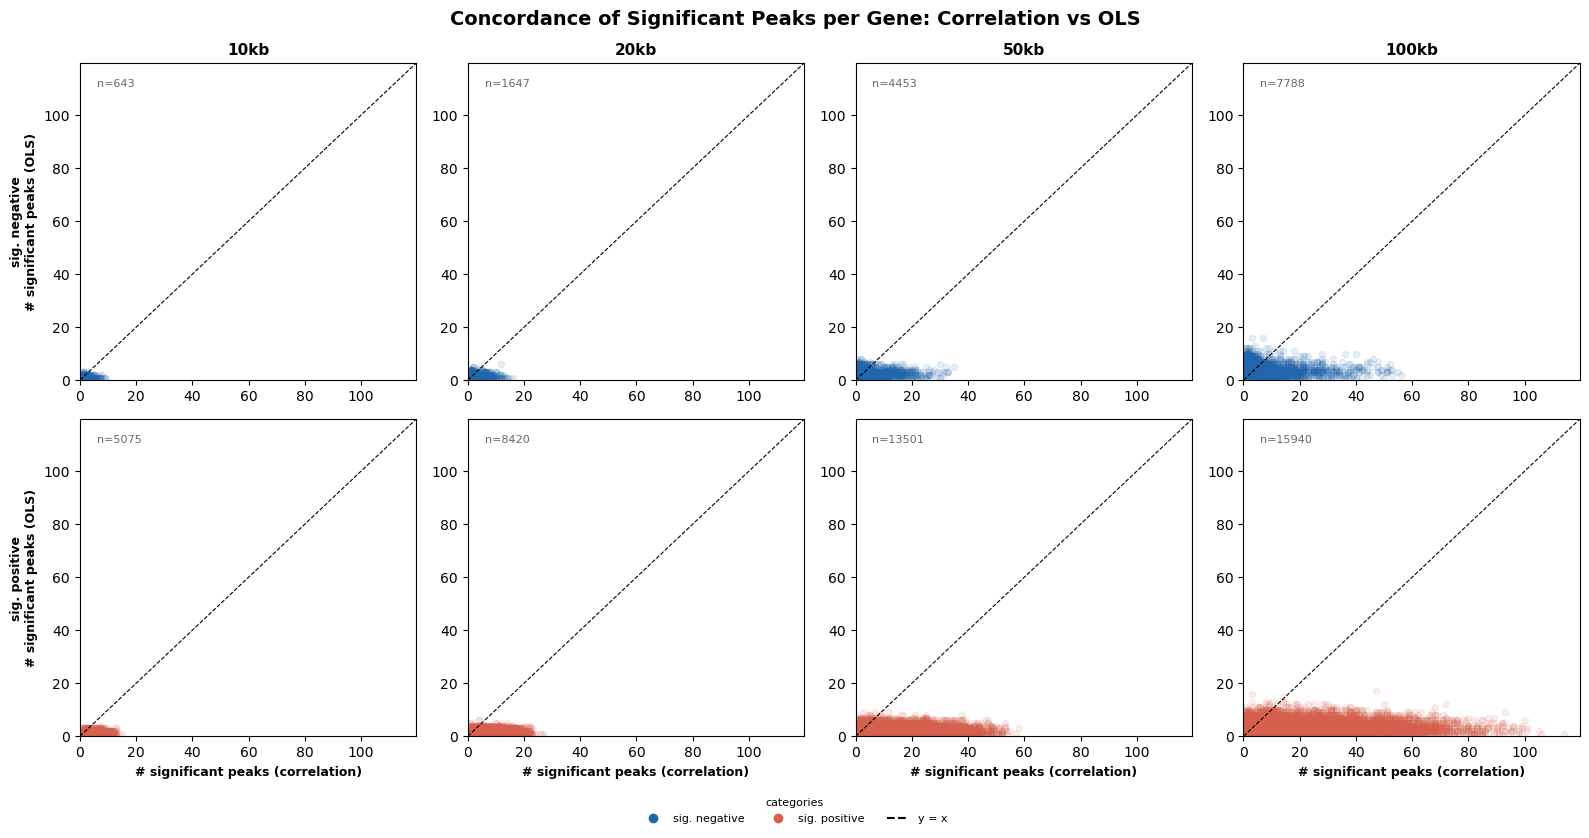

In [38]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["10kb", "20kb", "50kb", "100kb"], ordered=True,
)

plot_sig_df = plot_df[plot_df["category"] != "non-significant"].copy()

category_colors = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
}
category_order = ["sig. negative", "sig. positive"]

# plot: rows = categories, cols = windows, points colored by category 
fig, axes = plt.subplots(
    2, 4,
    figsize=(16, 8),
    sharex=False,
    sharey=False,
)

axis_max = (
    plot_sig_df[["count_cor", "count_ols"]]
    .max()
    .max()
    * 1.05
)

for row_i, category in enumerate(category_order):

    for col_i, window in enumerate(windows):

        ax = axes[row_i, col_i]

        data = plot_sig_df[
            (plot_sig_df["window"] == window)
            & (plot_sig_df["category"] == category)
        ]

        if data.empty:
            ax.set_axis_off()
            continue

        ax.scatter(
            data["count_cor"],
            data["count_ols"],
            color=category_colors[category],
            alpha=0.1,
            s=20,
        )

        # y = x reference line
        ax.plot(
            [0, axis_max],
            [0, axis_max],
            color="black",
            linestyle="--",
            linewidth=0.8,
        )

        ax.set_xlim(0, axis_max)
        ax.set_ylim(0, axis_max)

        if row_i == 0:
            ax.set_title(
                window,
                fontsize=11,
                fontweight="bold",
            )

        if col_i == 0:
            ax.set_ylabel(
                f"{category}\n# significant peaks (OLS)",
                fontsize=9,
                fontweight="bold",
            )

        if row_i == len(category_order) - 1:
            ax.set_xlabel(
                "# significant peaks (correlation)",
                fontsize=9,
                fontweight="bold",
            )

        n_genes = data["gene"].nunique()

        ax.text(
            0.05,
            0.95,
            f"n={n_genes}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            color="0.4",
        )

# Shared legend
handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        color=category_colors[c],
        label=c,
        markersize=6,
    )
    for c in category_order
]

handles.append(
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        label="y = x",
    )
)

fig.legend(
    handles=handles,
    title="categories",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    frameon=False, fontsize= 8,
    ncol=len(handles),
    title_fontsize=8
)

fig.suptitle(
    "Concordance of Significant Peaks per Gene: Correlation vs OLS",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
plt.show()


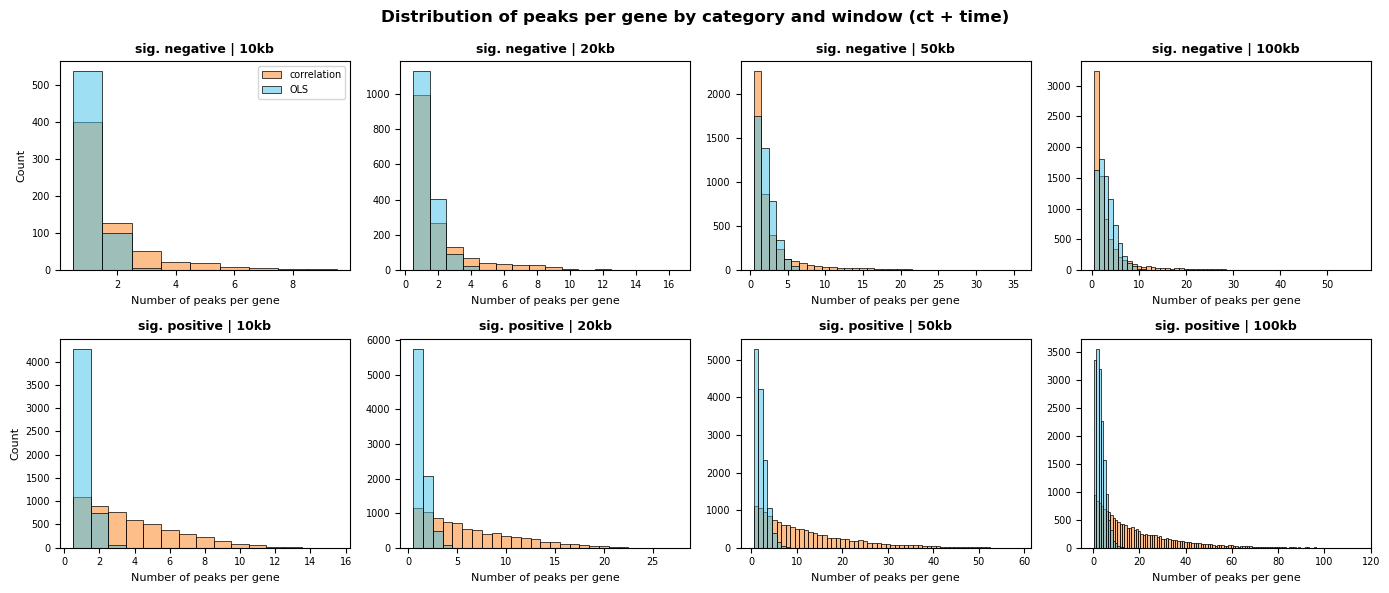

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"],
    ordered=True,
)

plot_df_non = plot_df[plot_df["category"] != "non-significant"].copy()
plot_df_non["category"] = pd.Categorical(
    plot_df_non["category"],
    categories=["sig. negative", "sig. positive"],
    ordered=True,
)

window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "sig. positive"]
method_colors = {"correlation": "#fd7e16", "OLS": "#40c1e9"}

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=False, sharey=False)

for row_idx, cat in enumerate(category_order):
    cat_data = plot_df_non[plot_df_non["category"] == cat]

    for col_idx, win in enumerate(window_labels):
        ax = axes[row_idx, col_idx]
        win_data = cat_data[cat_data["window"] == win]

        combined_counts = pd.concat([win_data["count_cor"], win_data["count_ols"]]).dropna()
        if combined_counts.empty:
            ax.set_axis_off()
            continue

        bin_edges = np.linspace(combined_counts.min(), combined_counts.max(), 16)
        if np.unique(bin_edges).size < 2:
            bin_edges = np.array([combined_counts.min() - 0.5, combined_counts.max() + 0.5])

        # Plot correlation histogram
        sns.histplot(
            win_data["count_cor"],
            #bins=bin_edges,
            alpha=0.5,
            label="correlation",
            color=method_colors["correlation"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax

        )
        # Plot OLS histogram
        sns.histplot(
            win_data["count_ols"],
            #bins=bin_edges,
            alpha=0.5,
            label="OLS",
            color=method_colors["OLS"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax
        )

        ax.set_xlabel("Number of peaks per gene", fontsize=8)
        ax.set_ylabel("Count" if col_idx == 0 else "", fontsize=8)
        ax.set_title(f"{cat} | {win}", fontsize=9, fontweight="bold")
        ax.tick_params(labelsize=7)

        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="upper right", fontsize=7)

fig.suptitle("Distribution of peaks per gene by category and window (ct + time)", fontsize=12, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

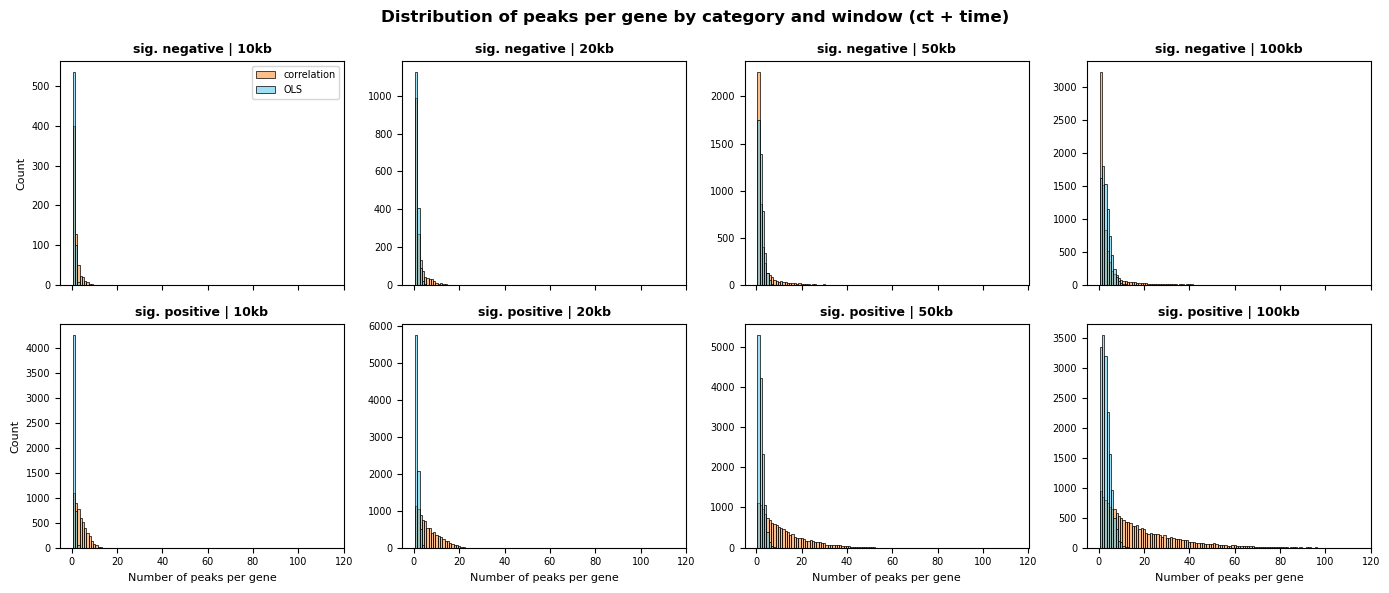

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"],
    ordered=True,
)

plot_df_non = plot_df[plot_df["category"] != "non-significant"].copy()
plot_df_non["category"] = pd.Categorical(
    plot_df_non["category"],
    categories=["sig. negative", "sig. positive"],
    ordered=True,
)

window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "sig. positive"]
method_colors = {"correlation": "#fd7e16", "OLS": "#40c1e9"}

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=False)

for row_idx, cat in enumerate(category_order):
    cat_data = plot_df_non[plot_df_non["category"] == cat]

    for col_idx, win in enumerate(window_labels):
        ax = axes[row_idx, col_idx]
        win_data = cat_data[cat_data["window"] == win]

        combined_counts = pd.concat([win_data["count_cor"], win_data["count_ols"]]).dropna()
        if combined_counts.empty:
            ax.set_axis_off()
            continue

        bin_edges = np.linspace(combined_counts.min(), combined_counts.max(), 16)
        if np.unique(bin_edges).size < 2:
            bin_edges = np.array([combined_counts.min() - 0.5, combined_counts.max() + 0.5])

        # Plot correlation histogram
        sns.histplot(
            win_data["count_cor"],
            #bins=bin_edges,
            alpha=0.5,
            label="correlation",
            color=method_colors["correlation"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax

        )
        # Plot OLS histogram
        sns.histplot(
            win_data["count_ols"],
            #bins=bin_edges,
            alpha=0.5,
            label="OLS",
            color=method_colors["OLS"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax
        )

        ax.set_xlabel("Number of peaks per gene", fontsize=8)
        ax.set_ylabel("Count" if col_idx == 0 else "", fontsize=8)
        ax.set_title(f"{cat} | {win}", fontsize=9, fontweight="bold")
        ax.tick_params(labelsize=7)

        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="upper right", fontsize=7)

fig.suptitle("Distribution of peaks per gene by category and window (ct + time)", fontsize=12, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

## Bootstrapping OLS for all windows
- saving only frequency of pos./neg. coefficient and average coefficient value of n iterations per peaks per gene

In [5]:
# OLS regression of gene expression on peak accessibility per gene (10kb window)
# 1) Bootstrap 1000 iterations, sampling min(n_peaks_total, n_samples-2) peaks per iteration and saving only 
# a) the fractions of how many of the sampled peaks are significant 
# b) the average coefficients of the significant peaks across iterations
# (with replacement only when n_peaks_total < n_select, deduplicated to keep OLS valid)

import numpy as np
import pandas as pd
import ast
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# ── configure window ──────────────────────────────────────────────────────────
window_label  = "10kb"
gene_peaks_df = gene_peaks_10kb

# ── result store ──────────────────────────────────────────────────────────────
ols_results = {}

# ── OLS loop per gene ─────────────────────────────────────────────────────────
for gene_id in gene_peaks_df["gene_id"]:

    assigned_peaks_raw = gene_peaks_df.loc[
        gene_peaks_df["gene_id"] == gene_id, "assigned_peaks"
    ].iloc[0]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = list(assigned_peaks_raw)

    assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct_time.var_names]

    if len(assigned_peaks) == 0:
        ols_results[gene_id] = {}
        continue

    y = np.asarray(pb_rna_ct_time[:, gene_id].X).ravel().astype(float)

    if np.std(y) == 0 or y.shape[0] < 2:
        ols_results[gene_id] = {}
        continue

    X_raw = np.asarray(pb_atac_ct_time[:, assigned_peaks].X).astype(float)
    n_samples     = X_raw.shape[0]
    n_peaks_total = X_raw.shape[1]

    # ── normalize ─────────────────────────────────────────────────────────────
    peak_means = X_raw.mean(axis=0)
    peak_stds  = X_raw.std(axis=0)

    constant_mask = peak_stds == 0
    if constant_mask.any():
        keep_mask      = ~constant_mask
        assigned_peaks = [p for p, keep in zip(assigned_peaks, keep_mask) if keep]
        X_raw          = X_raw[:, keep_mask]
        peak_means     = peak_means[keep_mask]
        peak_stds      = peak_stds[keep_mask]
        n_peaks_total  = X_raw.shape[1]

        if n_peaks_total == 0:
            ols_results[gene_id] = {}
            continue

    X_raw = (X_raw - peak_means) / peak_stds

    n_select = max(1, min(n_peaks_total, n_samples - 2))

    # ── bootstrap ─────────────────────────────────────────────────────────────
    n_iterations           = 1000
    significance_threshold = 0.05

    # accumulators: per peak across iterations
    sig_counts   = np.zeros(n_peaks_total, dtype=float)  # times significant
    iter_counts  = np.zeros(n_peaks_total, dtype=float)  # times sampled
    coef_sums    = np.zeros(n_peaks_total, dtype=float)  # sum of coefs when significant
                                                          # (for averaging later)

    for _ in range(n_iterations):
        replace = n_peaks_total < n_select
        sel_idx = np.random.choice(n_peaks_total, size=n_select, replace=replace)
        sel_idx = np.unique(sel_idx)

        X_sel = add_constant(X_raw[:, sel_idx], prepend=True)

        try:
            result  = OLS(y, X_sel).fit()
            pvalues = result.pvalues[1:]
            coefs   = result.params[1:]
        except Exception:
            continue

        for local_i, peak_i in enumerate(sel_idx):
            iter_counts[peak_i] += 1
            if pvalues[local_i] <= significance_threshold:
                sig_counts[peak_i]  += 1
                coef_sums[peak_i]   += coefs[local_i]

    # ── summarize per peak ────────────────────────────────────────────────────
    peak_summaries = {}
    for peak_i, peak_id in enumerate(assigned_peaks):
        if iter_counts[peak_i] == 0:
            continue

        n_sig = sig_counts[peak_i]

        peak_summaries[peak_id] = {
            "times_sampled":     int(iter_counts[peak_i]),
            "times_significant": int(n_sig),
            # a) fraction of iterations where peak was significant
            "significance_rate": n_sig / iter_counts[peak_i],
            # b) average coefficient across iterations where peak WAS significant
            #    (NaN if never significant — no coefs to average)
            "mean_coef_if_significant": coef_sums[peak_i] / n_sig if n_sig > 0 else np.nan,
        }

    ols_results[gene_id] = {
        "meta": {
            "n_samples":     n_samples,
            "n_peaks_total": n_peaks_total,
            "n_select":      n_select,
            "n_iterations":  n_iterations,
        },
        "peaks": peak_summaries,
    }

print(f"[{window_label}] Bootstrap complete — {len(ols_results)} genes processed")


# ── build tidy DataFrame ──────────────────────────────────────────────────────
all_rows = []

for gene_id, gene_data in ols_results.items():
    if not gene_data or "peaks" not in gene_data:
        continue

    meta = gene_data["meta"]

    for peak_id, stats in gene_data["peaks"].items():
        all_rows.append({
            "window":                   window_label,
            "gene":                     gene_id,
            "peak":                     peak_id,
            "n_samples":                meta["n_samples"],
            "n_peaks_total":            meta["n_peaks_total"],
            "n_select":                 meta["n_select"],
            "n_iterations":             meta["n_iterations"],
            "times_sampled":            stats["times_sampled"],
            "times_significant":        stats["times_significant"],
            "significance_rate":        stats["significance_rate"],
            "mean_coef_if_significant": stats["mean_coef_if_significant"],
        })

ols_res_10kb_brief_df = pd.DataFrame(all_rows)

print(f"\nBootstrap summary DataFrame: {ols_res_10kb_brief_df.shape[0]:,} peak–gene pairs")
print(ols_res_10kb_brief_df.head())

[10kb] Bootstrap complete — 19380 genes processed

Bootstrap summary DataFrame: 172,007 peak–gene pairs
  window   gene           peak  n_samples  n_peaks_total  n_select  \
0   10kb  rpl24    1-2372-3057        196             13        13   
1   10kb  rpl24    1-3427-4032        196             13        13   
2   10kb  rpl24    1-4469-7268        196             13        13   
3   10kb  rpl24    1-9541-9969        196             13        13   
4   10kb  rpl24  1-11007-12962        196             13        13   

   n_iterations  times_sampled  times_significant  significance_rate  \
0          1000           1000                  0                0.0   
1          1000           1000                  0                0.0   
2          1000           1000                  0                0.0   
3          1000           1000                  0                0.0   
4          1000           1000                  0                0.0   

   mean_coef_if_significant  
0           

In [6]:
#number of assigned peaks per gene in 10kb window
print("\nNumber of max. assigned peaks:")
assigned_peaks_counts = gene_peaks_10kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
print(assigned_peaks_counts.max())

print("\nNumber of times sampled (min and max):")
print(ols_res_10kb_brief_df['times_sampled'].min())
print(ols_res_10kb_brief_df['times_sampled'].max())
#count the number of significant peaks per gene at a threshold of 0.05
significant_peaks_per_gene = ols_res_10kb_brief_df[ols_res_10kb_brief_df["significance_rate"] >= 0.05].groupby("gene").size()
print("\nNumber of significant peaks per gene at threshold 0.05:")
print(significant_peaks_per_gene.head())

#save the gene names in significant_peaks_per_gene.head() to a list
significant_genes = significant_peaks_per_gene.head().index.tolist()

#number of assigned peaks of theses genes
assigned_peaks_counts = gene_peaks_10kb[gene_peaks_10kb["gene_id"].isin(significant_genes)].set_index("gene_id")["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
print("\nNumber of assigned peaks for the top significant genes:")
print(assigned_peaks_counts.head())

#mean of times sampled for the peaks 
print(ols_res_10kb_brief_df["times_sampled"].mean())



Number of max. assigned peaks:
17

Number of times sampled (min and max):
1000
1000

Number of significant peaks per gene at threshold 0.05:
gene
aaas     1
aadac    1
aak1a    1
aamdc    2
aamp     1
dtype: int64

Number of assigned peaks for the top significant genes:
gene_id
aamp     7
aak1a    9
aaas     6
aadac    9
aamdc    7
Name: assigned_peaks, dtype: int64
1000.0


In [7]:
# OLS regression of gene expression on peak accessibility per gene (20kb window)
# 1) Bootstrap 100 iterations, sampling min(n_peaks_total, n_samples-2) peaks per iteration and saving only 
# a) the fractions of how many of the sampled peaks are significant 
# b) the average coefficients of the significant peaks across iterations
# (with replacement only when n_peaks_total < n_select, deduplicated to keep OLS valid)

import numpy as np
import pandas as pd
import ast
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# ── configure window ──────────────────────────────────────────────────────────
window_label  = "20kb"
gene_peaks_df = gene_peaks_20kb

# ── result store ──────────────────────────────────────────────────────────────
ols_results = {}

# ── OLS loop per gene ─────────────────────────────────────────────────────────

# index the dataframe once before the loop
gene_peaks_indexed = gene_peaks_df.set_index("gene_id")

for gene_id in gene_peaks_indexed.index:
    assigned_peaks_raw = gene_peaks_indexed.loc[gene_id, "assigned_peaks"]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = list(assigned_peaks_raw)

    assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct_time.var_names]

    if len(assigned_peaks) == 0:
        ols_results[gene_id] = {}
        continue

    y = np.asarray(pb_rna_ct_time[:, gene_id].X).ravel().astype(float)

    if np.std(y) == 0 or y.shape[0] < 2:
        ols_results[gene_id] = {}
        continue

    X_raw = np.asarray(pb_atac_ct_time[:, assigned_peaks].X).astype(float)
    n_samples     = X_raw.shape[0]
    n_peaks_total = X_raw.shape[1]

    peak_means = X_raw.mean(axis=0)
    peak_stds  = X_raw.std(axis=0)

    constant_mask = peak_stds == 0
    if constant_mask.any():
        keep_mask      = ~constant_mask
        assigned_peaks = [p for p, keep in zip(assigned_peaks, keep_mask) if keep]
        X_raw          = X_raw[:, keep_mask]
        peak_means     = peak_means[keep_mask]
        peak_stds      = peak_stds[keep_mask]
        n_peaks_total  = X_raw.shape[1]

        if n_peaks_total == 0:
            ols_results[gene_id] = {}
            continue

    X_raw = (X_raw - peak_means) / peak_stds

    n_select = max(1, min(n_peaks_total, n_samples - 2))

    n_iterations           = 1000
    significance_threshold = 0.05

    sig_counts  = np.zeros(n_peaks_total, dtype=float)
    iter_counts = np.zeros(n_peaks_total, dtype=float)
    coef_sums   = np.zeros(n_peaks_total, dtype=float)

    for _ in range(n_iterations):
        replace = n_peaks_total < n_select
        sel_idx = np.random.choice(n_peaks_total, size=n_select, replace=replace)
        sel_idx = np.unique(sel_idx)

        X_sel = add_constant(X_raw[:, sel_idx], prepend=True)

        try:
            result  = OLS(y, X_sel).fit()
            pvalues = result.pvalues[1:]
            coefs   = result.params[1:]
        except Exception:
            continue

        sig_mask = pvalues <= significance_threshold
        iter_counts[sel_idx] += 1
        sig_counts[sel_idx]  += sig_mask.astype(float)
        coef_sums[sel_idx]   += np.where(sig_mask, coefs, 0.0)

    peak_summaries = {}
    for peak_i, peak_id in enumerate(assigned_peaks):
        if iter_counts[peak_i] == 0:
            continue

        n_sig = sig_counts[peak_i]
        peak_summaries[peak_id] = {
            "times_sampled":            int(iter_counts[peak_i]),
            "times_significant":        int(n_sig),
            "significance_rate":        n_sig / iter_counts[peak_i],
            "mean_coef_if_significant": coef_sums[peak_i] / n_sig if n_sig > 0 else np.nan,
        }

    ols_results[gene_id] = {
        "meta": {
            "n_samples":     n_samples,
            "n_peaks_total": n_peaks_total,
            "n_select":      n_select,
            "n_iterations":  n_iterations,
        },
        "peaks": peak_summaries,
    }

print(f"[{window_label}] Bootstrap complete — {len(ols_results)} genes processed")

# ── build tidy DataFrame ──────────────────────────────────────────────────────
all_rows = []

for gene_id, gene_data in ols_results.items():
    if not gene_data or "peaks" not in gene_data:
        continue

    meta = gene_data["meta"]

    for peak_id, stats in gene_data["peaks"].items():
        all_rows.append({
            "window":                   window_label,
            "gene":                     gene_id,
            "peak":                     peak_id,
            "n_samples":                meta["n_samples"],
            "n_peaks_total":            meta["n_peaks_total"],
            "n_select":                 meta["n_select"],
            "n_iterations":             meta["n_iterations"],
            "times_sampled":            stats["times_sampled"],
            "times_significant":        stats["times_significant"],
            "significance_rate":        stats["significance_rate"],
            "mean_coef_if_significant": stats["mean_coef_if_significant"],
        })

ols_res_20kb_brief_df = pd.DataFrame(all_rows)

print(f"\nBootstrap summary DataFrame: {ols_res_20kb_brief_df.shape[0]:,} peak–gene pairs")
print(ols_res_20kb_brief_df.head())

[20kb] Bootstrap complete — 19380 genes processed

Bootstrap summary DataFrame: 360,340 peak–gene pairs
  window   gene         peak  n_samples  n_peaks_total  n_select  \
0   20kb  rpl24     1-32-526        196             19        19   
1   20kb  rpl24  1-2372-3057        196             19        19   
2   20kb  rpl24  1-3427-4032        196             19        19   
3   20kb  rpl24  1-4469-7268        196             19        19   
4   20kb  rpl24  1-9541-9969        196             19        19   

   n_iterations  times_sampled  times_significant  significance_rate  \
0          1000           1000                  0                0.0   
1          1000           1000                  0                0.0   
2          1000           1000                  0                0.0   
3          1000           1000                  0                0.0   
4          1000           1000               1000                1.0   

   mean_coef_if_significant  
0                       

In [8]:
#number of assigned peaks per gene in 20kb window
print("\nNumber of max. assigned peaks:")
assigned_peaks_counts = gene_peaks_20kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
print(assigned_peaks_counts.max())

print("\nNumber of times sampled (min and max):")
print(ols_res_20kb_brief_df['times_sampled'].min())
print(ols_res_20kb_brief_df['times_sampled'].max())
#count the number of significant peaks per gene at a threshold of 0.05
significant_peaks_per_gene = ols_res_20kb_brief_df[ols_res_20kb_brief_df["significance_rate"] >= 0.05].groupby("gene").size()
print("\nNumber of significant peaks per gene at threshold 0.05:")
print(significant_peaks_per_gene.head())

#save the gene names in significant_peaks_per_gene.head() to a list
significant_genes = significant_peaks_per_gene.head().index.tolist()

#number of assigned peaks of theses genes
assigned_peaks_counts = gene_peaks_20kb[gene_peaks_20kb["gene_id"].isin(significant_genes)].set_index("gene_id")["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
print("\nNumber of assigned peaks for the top significant genes:")
print(assigned_peaks_counts.head())

#mean of times sampled for the peaks 
print(ols_res_20kb_brief_df["times_sampled"].mean())


Number of max. assigned peaks:
32

Number of times sampled (min and max):
1000
1000

Number of significant peaks per gene at threshold 0.05:
gene
a1cf       1
a2ml       1
aaas       2
aadac      1
aadacl4    1
dtype: int64

Number of assigned peaks for the top significant genes:
gene_id
aaas       19
aadacl4    19
a1cf       20
aadac      16
a2ml       22
Name: assigned_peaks, dtype: int64
1000.0


In [9]:
# OLS regression of gene expression on peak accessibility per gene (50kb window)
# 1) Bootstrap 100 iterations, sampling min(n_peaks_total, n_samples-2) peaks per iteration and saving only 
# a) the fractions of how many of the sampled peaks are significant 
# b) the average coefficients of the significant peaks across iterations
# (with replacement only when n_peaks_total < n_select, deduplicated to keep OLS valid)

import numpy as np
import pandas as pd
import ast
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# ── configure window ──────────────────────────────────────────────────────────
window_label  = "50kb"
gene_peaks_df = gene_peaks_50kb

# ── result store ──────────────────────────────────────────────────────────────
ols_results = {}

# ── OLS loop per gene ─────────────────────────────────────────────────────────

# index the dataframe once before the loop
gene_peaks_indexed = gene_peaks_df.set_index("gene_id")

for gene_id in gene_peaks_indexed.index:
    assigned_peaks_raw = gene_peaks_indexed.loc[gene_id, "assigned_peaks"]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = list(assigned_peaks_raw)

    assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct_time.var_names]

    if len(assigned_peaks) == 0:
        ols_results[gene_id] = {}
        continue

    y = np.asarray(pb_rna_ct_time[:, gene_id].X).ravel().astype(float)

    if np.std(y) == 0 or y.shape[0] < 2:
        ols_results[gene_id] = {}
        continue

    X_raw = np.asarray(pb_atac_ct_time[:, assigned_peaks].X).astype(float)
    n_samples     = X_raw.shape[0]
    n_peaks_total = X_raw.shape[1]

    peak_means = X_raw.mean(axis=0)
    peak_stds  = X_raw.std(axis=0)

    constant_mask = peak_stds == 0
    if constant_mask.any():
        keep_mask      = ~constant_mask
        assigned_peaks = [p for p, keep in zip(assigned_peaks, keep_mask) if keep]
        X_raw          = X_raw[:, keep_mask]
        peak_means     = peak_means[keep_mask]
        peak_stds      = peak_stds[keep_mask]
        n_peaks_total  = X_raw.shape[1]

        if n_peaks_total == 0:
            ols_results[gene_id] = {}
            continue

    X_raw = (X_raw - peak_means) / peak_stds

    n_select = max(1, min(n_peaks_total, n_samples - 2))

    n_iterations           = 1000
    significance_threshold = 0.05

    sig_counts  = np.zeros(n_peaks_total, dtype=float)
    iter_counts = np.zeros(n_peaks_total, dtype=float)
    coef_sums   = np.zeros(n_peaks_total, dtype=float)

    for _ in range(n_iterations):
        replace = n_peaks_total < n_select
        sel_idx = np.random.choice(n_peaks_total, size=n_select, replace=replace)
        sel_idx = np.unique(sel_idx)

        X_sel = add_constant(X_raw[:, sel_idx], prepend=True)

        try:
            result  = OLS(y, X_sel).fit()
            pvalues = result.pvalues[1:]
            coefs   = result.params[1:]
        except Exception:
            continue

        sig_mask = pvalues <= significance_threshold
        iter_counts[sel_idx] += 1
        sig_counts[sel_idx]  += sig_mask.astype(float)
        coef_sums[sel_idx]   += np.where(sig_mask, coefs, 0.0)

    peak_summaries = {}
    for peak_i, peak_id in enumerate(assigned_peaks):
        if iter_counts[peak_i] == 0:
            continue

        n_sig = sig_counts[peak_i]
        peak_summaries[peak_id] = {
            "times_sampled":            int(iter_counts[peak_i]),
            "times_significant":        int(n_sig),
            "significance_rate":        n_sig / iter_counts[peak_i],
            "mean_coef_if_significant": coef_sums[peak_i] / n_sig if n_sig > 0 else np.nan,
        }

    ols_results[gene_id] = {
        "meta": {
            "n_samples":     n_samples,
            "n_peaks_total": n_peaks_total,
            "n_select":      n_select,
            "n_iterations":  n_iterations,
        },
        "peaks": peak_summaries,
    }

print(f"[{window_label}] Bootstrap complete — {len(ols_results)} genes processed")

# ── build tidy DataFrame ──────────────────────────────────────────────────────
all_rows = []

for gene_id, gene_data in ols_results.items():
    if not gene_data or "peaks" not in gene_data:
        continue

    meta = gene_data["meta"]

    for peak_id, stats in gene_data["peaks"].items():
        all_rows.append({
            "window":                   window_label,
            "gene":                     gene_id,
            "peak":                     peak_id,
            "n_samples":                meta["n_samples"],
            "n_peaks_total":            meta["n_peaks_total"],
            "n_select":                 meta["n_select"],
            "n_iterations":             meta["n_iterations"],
            "times_sampled":            stats["times_sampled"],
            "times_significant":        stats["times_significant"],
            "significance_rate":        stats["significance_rate"],
            "mean_coef_if_significant": stats["mean_coef_if_significant"],
        })

ols_res_50kb_brief_df = pd.DataFrame(all_rows)

print(f"\nBootstrap summary DataFrame: {ols_res_50kb_brief_df.shape[0]:,} peak–gene pairs")
print(ols_res_50kb_brief_df.head())

[50kb] Bootstrap complete — 19380 genes processed

Bootstrap summary DataFrame: 922,652 peak–gene pairs
  window   gene         peak  n_samples  n_peaks_total  n_select  \
0   50kb  rpl24     1-32-526        196             31        31   
1   50kb  rpl24  1-2372-3057        196             31        31   
2   50kb  rpl24  1-3427-4032        196             31        31   
3   50kb  rpl24  1-4469-7268        196             31        31   
4   50kb  rpl24  1-9541-9969        196             31        31   

   n_iterations  times_sampled  times_significant  significance_rate  \
0          1000           1000                  0                0.0   
1          1000           1000                  0                0.0   
2          1000           1000                  0                0.0   
3          1000           1000                  0                0.0   
4          1000           1000               1000                1.0   

   mean_coef_if_significant  
0                       

In [10]:
#number of assigned peaks per gene in 50kb window
print("\nNumber of max. assigned peaks:")
assigned_peaks_counts = gene_peaks_50kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
print(assigned_peaks_counts.max())

print("\nNumber of times sampled (min and max):")
print(ols_res_50kb_brief_df['times_sampled'].min())
print(ols_res_50kb_brief_df['times_sampled'].max())
#count the number of significant peaks per gene at a threshold of 0.05
significant_peaks_per_gene = ols_res_50kb_brief_df[ols_res_50kb_brief_df["significance_rate"] >= 0.05].groupby("gene").size()
print("\nNumber of significant peaks per gene at threshold 0.05:")
print(significant_peaks_per_gene.head())

#save the gene names in significant_peaks_per_gene.head() to a list
significant_genes = significant_peaks_per_gene.head().index.tolist()

#number of assigned peaks of theses genes
assigned_peaks_counts = gene_peaks_50kb[gene_peaks_50kb["gene_id"].isin(significant_genes)].set_index("gene_id")["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
print("\nNumber of assigned peaks for the top significant genes:")
print(assigned_peaks_counts.head())

#mean of times sampled for the peaks 
print(ols_res_50kb_brief_df["times_sampled"].mean())


Number of max. assigned peaks:
69

Number of times sampled (min and max):
1000
1000

Number of significant peaks per gene at threshold 0.05:
gene
a1cf     3
a2ml     3
aaas     9
aacs     4
aadac    2
dtype: int64

Number of assigned peaks for the top significant genes:
gene_id
aacs     47
aaas     51
a1cf     45
aadac    52
a2ml     38
Name: assigned_peaks, dtype: int64
1000.0


In [11]:
# OLS regression of gene expression on peak accessibility per gene (100kb window)
# 1) Bootstrap 100 iterations, sampling min(n_peaks_total, n_samples-2) peaks per iteration and saving only 
# a) the fractions of how many of the sampled peaks are significant 
# b) the average coefficients of the significant peaks across iterations
# (with replacement only when n_peaks_total < n_select, deduplicated to keep OLS valid)

import numpy as np
import pandas as pd
import ast
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# ── configure window ──────────────────────────────────────────────────────────
window_label  = "100kb"
gene_peaks_df = gene_peaks_100kb

# ── result store ──────────────────────────────────────────────────────────────
ols_results = {}

# ── OLS loop per gene ─────────────────────────────────────────────────────────

# index the dataframe once before the loop
gene_peaks_indexed = gene_peaks_df.set_index("gene_id")

for gene_id in gene_peaks_indexed.index:
    assigned_peaks_raw = gene_peaks_indexed.loc[gene_id, "assigned_peaks"]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = list(assigned_peaks_raw)

    assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct_time.var_names]

    if len(assigned_peaks) == 0:
        ols_results[gene_id] = {}
        continue

    y = np.asarray(pb_rna_ct_time[:, gene_id].X).ravel().astype(float)

    if np.std(y) == 0 or y.shape[0] < 2:
        ols_results[gene_id] = {}
        continue

    X_raw = np.asarray(pb_atac_ct_time[:, assigned_peaks].X).astype(float)
    n_samples     = X_raw.shape[0]
    n_peaks_total = X_raw.shape[1]

    peak_means = X_raw.mean(axis=0)
    peak_stds  = X_raw.std(axis=0)

    constant_mask = peak_stds == 0
    if constant_mask.any():
        keep_mask      = ~constant_mask
        assigned_peaks = [p for p, keep in zip(assigned_peaks, keep_mask) if keep]
        X_raw          = X_raw[:, keep_mask]
        peak_means     = peak_means[keep_mask]
        peak_stds      = peak_stds[keep_mask]
        n_peaks_total  = X_raw.shape[1]

        if n_peaks_total == 0:
            ols_results[gene_id] = {}
            continue

    X_raw = (X_raw - peak_means) / peak_stds

    n_select = max(1, min(n_peaks_total, n_samples - 2))

    n_iterations           = 1000
    significance_threshold = 0.05

    sig_counts  = np.zeros(n_peaks_total, dtype=float)
    iter_counts = np.zeros(n_peaks_total, dtype=float)
    coef_sums   = np.zeros(n_peaks_total, dtype=float)

    for _ in range(n_iterations):
        replace = n_peaks_total < n_select
        sel_idx = np.random.choice(n_peaks_total, size=n_select, replace=replace)
        sel_idx = np.unique(sel_idx)

        X_sel = add_constant(X_raw[:, sel_idx], prepend=True)

        try:
            result  = OLS(y, X_sel).fit()
            pvalues = result.pvalues[1:]
            coefs   = result.params[1:]
        except Exception:
            continue

        sig_mask = pvalues <= significance_threshold
        iter_counts[sel_idx] += 1
        sig_counts[sel_idx]  += sig_mask.astype(float)
        coef_sums[sel_idx]   += np.where(sig_mask, coefs, 0.0)

    peak_summaries = {}
    for peak_i, peak_id in enumerate(assigned_peaks):
        if iter_counts[peak_i] == 0:
            continue

        n_sig = sig_counts[peak_i]
        peak_summaries[peak_id] = {
            "times_sampled":            int(iter_counts[peak_i]),
            "times_significant":        int(n_sig),
            "significance_rate":        n_sig / iter_counts[peak_i],
            "mean_coef_if_significant": coef_sums[peak_i] / n_sig if n_sig > 0 else np.nan,
        }

    ols_results[gene_id] = {
        "meta": {
            "n_samples":     n_samples,
            "n_peaks_total": n_peaks_total,
            "n_select":      n_select,
            "n_iterations":  n_iterations,
        },
        "peaks": peak_summaries,
    }

print(f"[{window_label}] Bootstrap complete — {len(ols_results)} genes processed")

# ── build tidy DataFrame ──────────────────────────────────────────────────────
all_rows = []

for gene_id, gene_data in ols_results.items():
    if not gene_data or "peaks" not in gene_data:
        continue

    meta = gene_data["meta"]

    for peak_id, stats in gene_data["peaks"].items():
        all_rows.append({
            "window":                   window_label,
            "gene":                     gene_id,
            "peak":                     peak_id,
            "n_samples":                meta["n_samples"],
            "n_peaks_total":            meta["n_peaks_total"],
            "n_select":                 meta["n_select"],
            "n_iterations":             meta["n_iterations"],
            "times_sampled":            stats["times_sampled"],
            "times_significant":        stats["times_significant"],
            "significance_rate":        stats["significance_rate"],
            "mean_coef_if_significant": stats["mean_coef_if_significant"],
        })

ols_res_100kb_brief_df = pd.DataFrame(all_rows)

print(f"\nBootstrap summary DataFrame: {ols_res_100kb_brief_df.shape[0]:,} peak–gene pairs")
print(ols_res_100kb_brief_df.head())

[100kb] Bootstrap complete — 19380 genes processed

Bootstrap summary DataFrame: 1,853,529 peak–gene pairs
  window   gene         peak  n_samples  n_peaks_total  n_select  \
0  100kb  rpl24     1-32-526        196             57        57   
1  100kb  rpl24  1-2372-3057        196             57        57   
2  100kb  rpl24  1-3427-4032        196             57        57   
3  100kb  rpl24  1-4469-7268        196             57        57   
4  100kb  rpl24  1-9541-9969        196             57        57   

   n_iterations  times_sampled  times_significant  significance_rate  \
0          1000           1000                  0                0.0   
1          1000           1000                  0                0.0   
2          1000           1000                  0                0.0   
3          1000           1000               1000                1.0   
4          1000           1000                  0                0.0   

   mean_coef_if_significant  
0                    

In [12]:
#number of assigned peaks per gene in 100kb window
print("\nNumber of max. assigned peaks:")
assigned_peaks_counts = gene_peaks_100kb["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
print(assigned_peaks_counts.max())

print("\nNumber of times sampled (min and max):")
print(ols_res_100kb_brief_df['times_sampled'].min())
print(ols_res_100kb_brief_df['times_sampled'].max())
#count the number of significant peaks per gene at a threshold of 0.05
significant_peaks_per_gene = ols_res_100kb_brief_df[ols_res_100kb_brief_df["significance_rate"] >= 0.05].groupby("gene").size()
print("\nNumber of significant peaks per gene at threshold 0.05:")
print(significant_peaks_per_gene.head())

#save the gene names in significant_peaks_per_gene.head() to a list
significant_genes = significant_peaks_per_gene.head().index.tolist()

#number of assigned peaks of theses genes
assigned_peaks_counts = gene_peaks_100kb[gene_peaks_100kb["gene_id"].isin(significant_genes)].set_index("gene_id")["assigned_peaks"].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
print("\nNumber of assigned peaks for the top significant genes:")
print(assigned_peaks_counts.head())

#mean of times sampled for the peaks 
print(ols_res_100kb_brief_df["times_sampled"].mean())


Number of max. assigned peaks:
125

Number of times sampled (min and max):
1000
1000

Number of significant peaks per gene at threshold 0.05:
gene
a1cf        6
aaas        8
aacs        1
aadac       4
aadacl4    17
dtype: int64

Number of assigned peaks for the top significant genes:
gene_id
aacs        88
aaas       110
aadacl4    103
a1cf        95
aadac      100
Name: assigned_peaks, dtype: int64
1000.0


In [13]:
# summarizing all brief ols results into a dataframe
ols_res_all_windows_brief_df = pd.concat(
    [
        ols_res_10kb_brief_df,
        ols_res_20kb_brief_df,
        ols_res_50kb_brief_df,
        ols_res_100kb_brief_df,
    ],
    ignore_index=True,
)

ols_res_all_windows_brief_df["window"] = pd.Categorical(
    ols_res_all_windows_brief_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)

print(f"Combined DataFrame: {ols_res_all_windows_brief_df.shape[0]:,} peak–gene pairs")
print(f"Windows: {ols_res_all_windows_brief_df['window'].value_counts().sort_index()}")
print(ols_res_all_windows_brief_df.head())

#save the combined dataframe to a csv file
ols_res_all_windows_brief_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/ols_bootstrap_brief_ct_time_results.csv.gz", index=False)

Combined DataFrame: 3,308,528 peak–gene pairs
Windows: window
10kb      172007
20kb      360340
50kb      922652
100kb    1853529
Name: count, dtype: int64
  window   gene           peak  n_samples  n_peaks_total  n_select  \
0   10kb  rpl24    1-2372-3057        196             13        13   
1   10kb  rpl24    1-3427-4032        196             13        13   
2   10kb  rpl24    1-4469-7268        196             13        13   
3   10kb  rpl24    1-9541-9969        196             13        13   
4   10kb  rpl24  1-11007-12962        196             13        13   

   n_iterations  times_sampled  times_significant  significance_rate  \
0          1000           1000                  0                0.0   
1          1000           1000                  0                0.0   
2          1000           1000                  0                0.0   
3          1000           1000                  0                0.0   
4          1000           1000                  0              

In [ ]:
#count significant peaks per gene per window
sig_peaks_per_gene = (
    ols_res_all_windows_brief_df
    .groupby(["window", "gene"])
    .agg(
        n_peaks_total        = ("peak", "count"),
        n_significant        = ("significance_rate", lambda x: (x > 0).sum()),
        n_sig_05             = ("significance_rate", lambda x: (x >= 0.05).sum()),
        n_sig_10             = ("significance_rate", lambda x: (x >= 0.10).sum()),
        n_sig_25             = ("significance_rate", lambda x: (x >= 0.25).sum()),
    )
    .reset_index()
)

sig_peaks_per_gene["window"] = pd.Categorical(
    sig_peaks_per_gene["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True,
)

print(sig_peaks_per_gene.head(20))

/tmp/ipykernel_3456117/3403716294.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["window", "gene"])


   window      gene  n_peaks_total  n_significant  n_sig_05  n_sig_10  \
0    10kb      a1cf             11            0.0       0.0       0.0   
1    10kb      a2ml             11            0.0       0.0       0.0   
2    10kb      aaas              6            1.0       1.0       1.0   
3    10kb      aacs             10            0.0       0.0       0.0   
4    10kb     aadac              9            1.0       1.0       1.0   
5    10kb   aadacl4             10            0.0       0.0       0.0   
6    10kb     aadat              9            0.0       0.0       0.0   
7    10kb     aagab              7            0.0       0.0       0.0   
8    10kb     aak1a              9            1.0       1.0       1.0   
9    10kb     aak1b              9            0.0       0.0       0.0   
10   10kb     aamdc              7            2.0       2.0       2.0   
11   10kb      aamp              7            1.0       1.0       1.0   
12   10kb    aanat1              7            1.0  

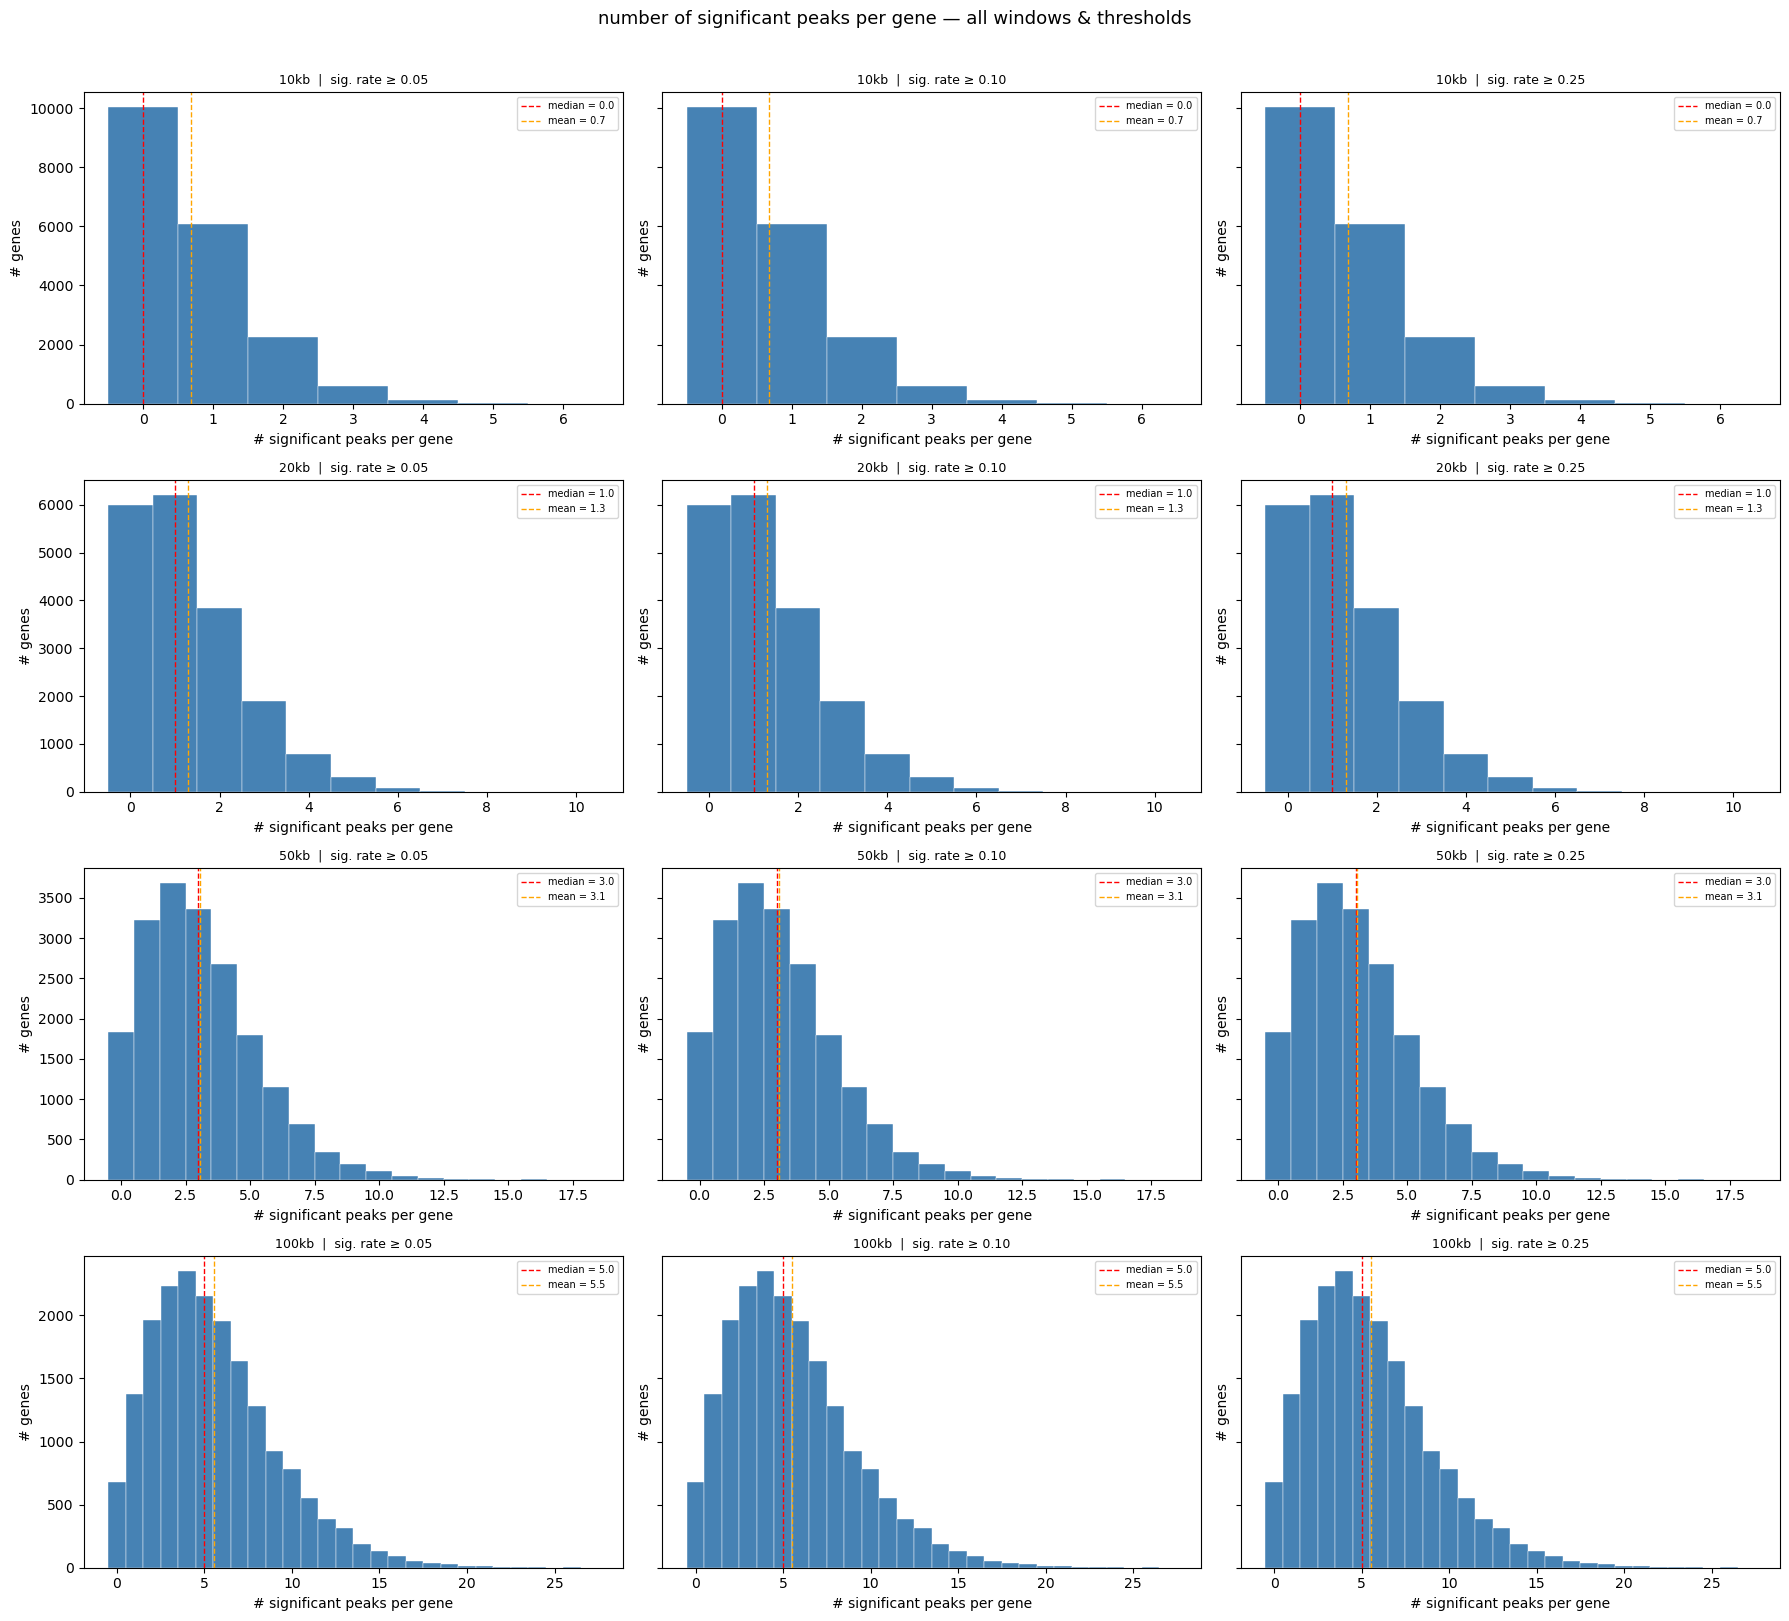

In [15]:
#same plot but row = windows & col = thresholds
import matplotlib.pyplot as plt

thresholds     = ["n_sig_05", "n_sig_10", "n_sig_25"]
threshold_labs = ["≥ 0.05",   "≥ 0.10",   "≥ 0.25"]
windows        = ["10kb", "20kb", "50kb", "100kb"]

fig, axes = plt.subplots(
    len(windows), len(thresholds),
    figsize=(18, 16),
    sharey="row",   # same y scale across thresholds within a window row
)

for row_i, window in enumerate(windows):
    for col_i, (thresh_col, thresh_lab) in enumerate(zip(thresholds, threshold_labs)):
        ax = axes[row_i, col_i]

        data = sig_peaks_per_gene.loc[
            sig_peaks_per_gene["window"] == window, thresh_col
        ]

        ax.hist(
            data,
            bins=range(0, int(data.max()) + 2),
            edgecolor="white",
            linewidth=0.3,
            color="steelblue",
            align="left",
        )

        ax.axvline(data.median(), color="red",    linestyle="--",
                   linewidth=1, label=f"median = {data.median():.1f}")
        ax.axvline(data.mean(),   color="orange", linestyle="--",
                   linewidth=1, label=f"mean = {data.mean():.1f}")

        ax.set_title(f"{window}  |  sig. rate {thresh_lab}", fontsize=9)
        ax.set_xlabel("# significant peaks per gene")
        ax.set_ylabel("# genes")
        ax.legend(fontsize=7)

plt.suptitle(
    "number of significant peaks per gene — all windows & thresholds",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

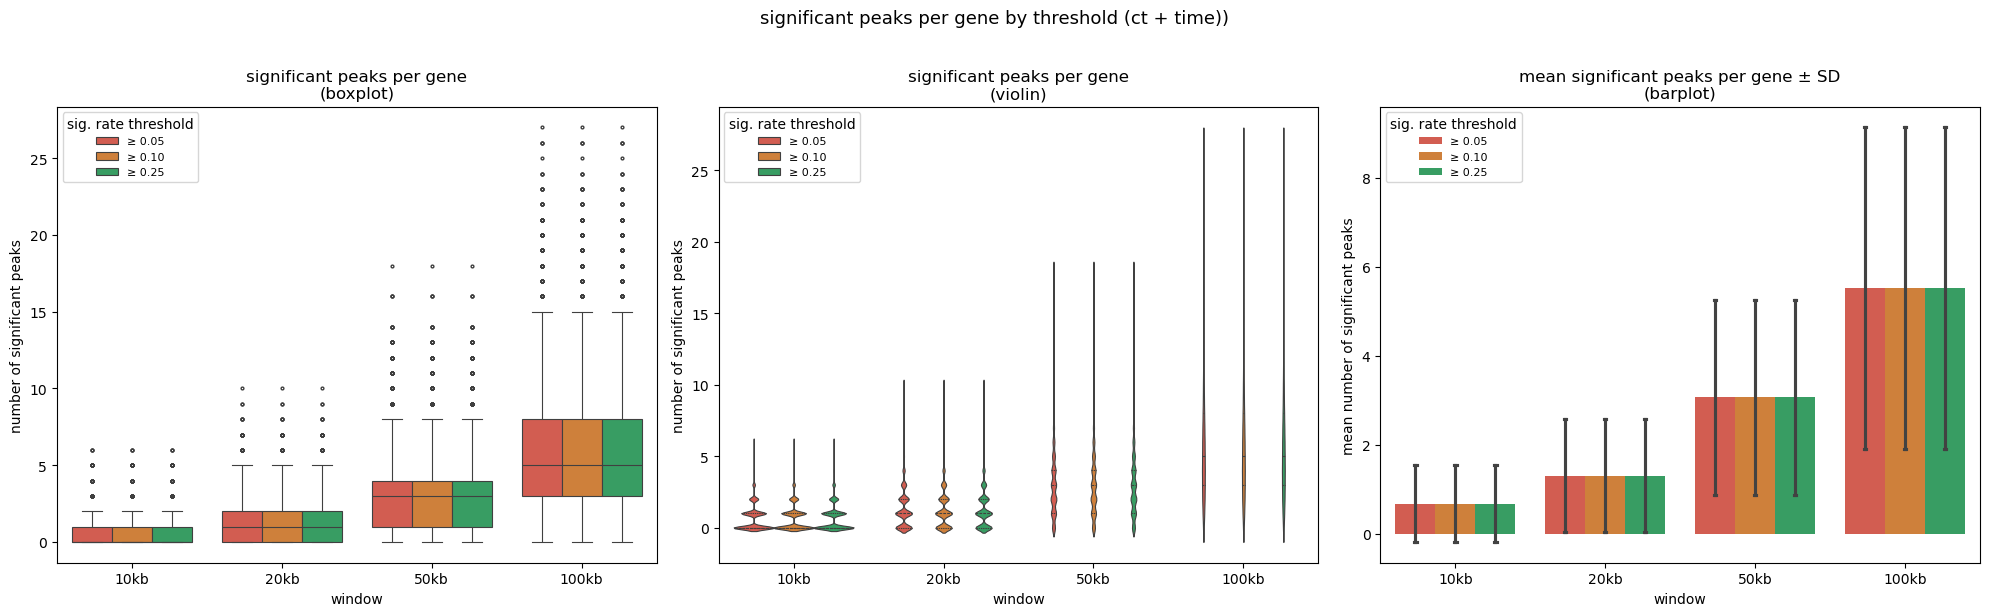

In [30]:
# number of sig. peaks on only 50kb and 100kb windows
import seaborn as sns
import matplotlib.pyplot as plt

# melt to long format so seaborn can split by threshold
sig_peaks_long = sig_peaks_per_gene.melt(
    id_vars=["window", "gene", "n_peaks_total"],
    value_vars=["n_sig_05", "n_sig_10", "n_sig_25"],
    var_name="threshold",
    value_name="n_sig",
)

# make threshold labels readable
sig_peaks_long["threshold"] = sig_peaks_long["threshold"].map({
    "n_sig_05": "≥ 0.05",
    "n_sig_10": "≥ 0.10",
    "n_sig_25": "≥ 0.25",
})

windows = ["50kb", "100kb"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for col_i, window in enumerate(windows):
    ax = axes[col_i]
    data = sig_peaks_long[sig_peaks_long["window"] == window]

# ── 1. boxplot: n significant peaks per gene, by window and threshold ─────────
sns.boxplot(
    data=sig_peaks_long,
    x="window", y="n_sig", hue="threshold",
    palette=["#e74c3c", "#e67e22", "#27ae60"],
    linewidth=0.8, fliersize=2,
    ax=axes[0],
)
axes[0].set_title("significant peaks per gene\n(boxplot)")
axes[0].set_xlabel("window")
axes[0].set_ylabel("number of significant peaks")
axes[0].legend(title="sig. rate threshold", fontsize=8)

# ── 2. violinplot: distribution shape per window and threshold ─────────────────
sns.violinplot(
    data=sig_peaks_long,
    x="window", y="n_sig", hue="threshold",
    palette=["#e74c3c", "#e67e22", "#27ae60"],
    linewidth=0.8, inner="quartile",
    ax=axes[1],
)
axes[1].set_title("significant peaks per gene\n(violin)")
axes[1].set_xlabel("window")
axes[1].set_ylabel("number of significant peaks")
axes[1].legend(title="sig. rate threshold", fontsize=8)

# ── 3. barplot: mean n significant peaks per gene, by window and threshold ─────
sns.barplot(
    data=sig_peaks_long,
    x="window", y="n_sig", hue="threshold",
    palette=["#e74c3c", "#e67e22", "#27ae60"],
    errorbar="sd", capsize=0.05,
    ax=axes[2],
)
axes[2].set_title("mean significant peaks per gene ± SD\n(barplot)")
axes[2].set_xlabel("window")
axes[2].set_ylabel("mean number of significant peaks")
axes[2].legend(title="sig. rate threshold", fontsize=8)

plt.suptitle(
    "significant peaks per gene by threshold (ct + time))",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()